# PCA - Housing

In [368]:
import pandas as pd
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

## Read dataset

In [369]:
df_housing = pd.read_csv("./dataset/housing.csv")
df_housing.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


In [370]:
df_housing.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


## Data Adjustment

In [371]:
df_housing['mainroad'] = df_housing['mainroad'].map({ 'yes': 1, 'no': 0 })
df_housing['guestroom'] = df_housing['guestroom'].map({ 'yes': 1, 'no': 0 })
df_housing['basement'] = df_housing['basement'].map({ 'yes': 1, 'no': 0 })
df_housing['hotwaterheating'] = df_housing['hotwaterheating'].map({ 'yes': 1, 'no': 0 })
df_housing['airconditioning'] = df_housing['airconditioning'].map({ 'yes': 1, 'no': 0 })
df_housing['prefarea'] = df_housing['prefarea'].map({ 'yes': 1, 'no': 0 })

df_model = df_housing.copy()
df_housing = pd.get_dummies(df_housing, columns=['furnishingstatus'])

## Data Analysis

### Univariate Analysis

Price Distribution

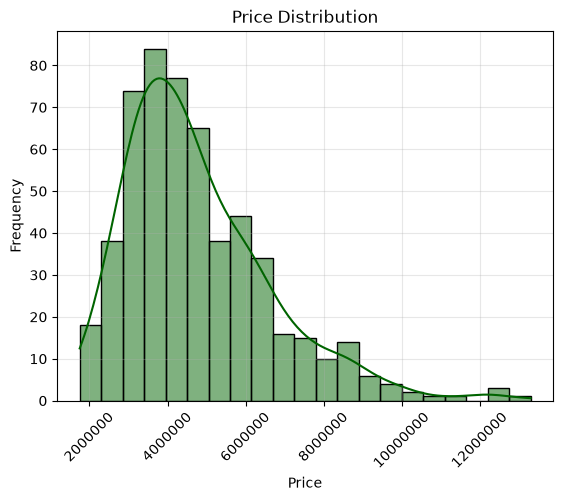

In [372]:
ax = sns.histplot(
  kde=True,
  data=df_housing,
  x='price',
  color='darkgreen',
)
plt.title("Price Distribution")
plt.ylabel("Frequency")
plt.xlabel("Price")
plt.grid(visible=True, alpha=0.3)
ax.ticklabel_format(style='plain', axis='both')
ax.tick_params(axis='x', rotation=45)

#### Area Distribution 

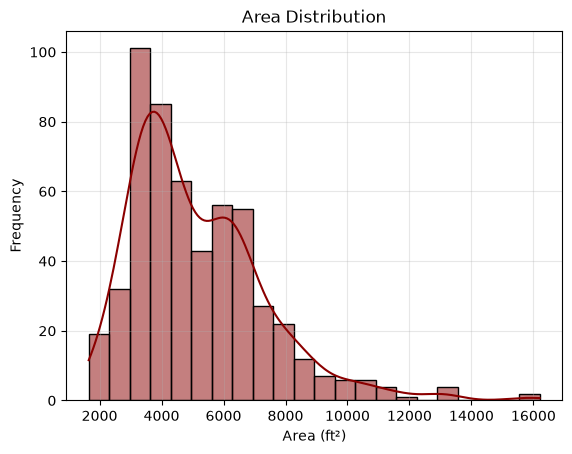

In [373]:
ax = sns.histplot(
  kde=True,
  data=df_housing,
  x='area',
  color='darkred',
)
plt.title("Area Distribution")
plt.ylabel("Frequency")
plt.xlabel("Area (ft²)")
plt.grid(visible=True, alpha=0.3)

#### Furnishing Status Proportion

/tmp/ipykernel_96023/2441464939.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(['Unfurnished', 'Semi-Furnished', 'Furnished'])


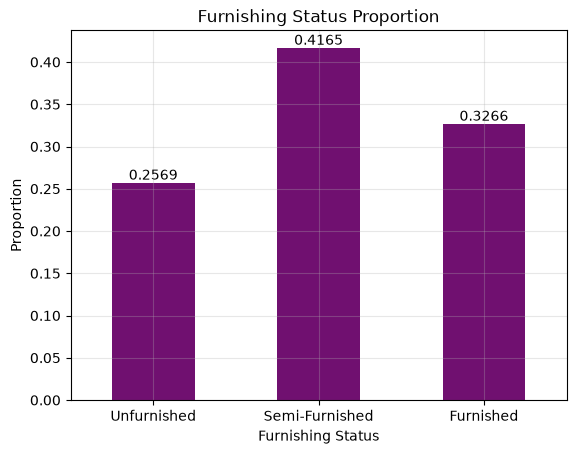

In [374]:
fs_table = df_model.value_counts('furnishingstatus', normalize=True).sort_index(ascending=True) # type: ignore
ax = sns.barplot(
  fs_table, # type: ignore
  color='purple',
  width=0.5,
)
ax.set_xticklabels(['Unfurnished', 'Semi-Furnished', 'Furnished'])
for container in ax.containers:
  ax.bar_label(container, fmt='%.4f', label_type='edge') # type: ignore
plt.ylabel("Proportion")
plt.xlabel("Furnishing Status")
plt.title("Furnishing Status Proportion")
plt.grid(visible=True, alpha=0.3)

#### Number of Bedrooms Proportion

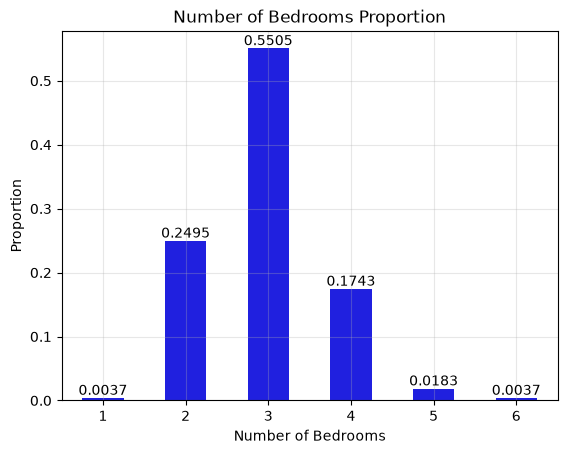

In [375]:
bedrooms_table = df_housing.value_counts("bedrooms", normalize=True) # type: ignore
ax = sns.barplot(
  bedrooms_table, # type: ignore
  color='blue',
  width=0.5,
)
for container in ax.containers:
    ax.bar_label(container, fmt='%.4f' ,label_type='edge') #type: ignore
plt.title("Number of Bedrooms Proportion")
plt.xlabel("Number of Bedrooms")
plt.ylabel("Proportion")
plt.grid(visible=True, alpha=0.3)

### Bivariare Analysis

#### Pearson Correlation

Text(0.5, 1.0, 'Pearson Correlation')

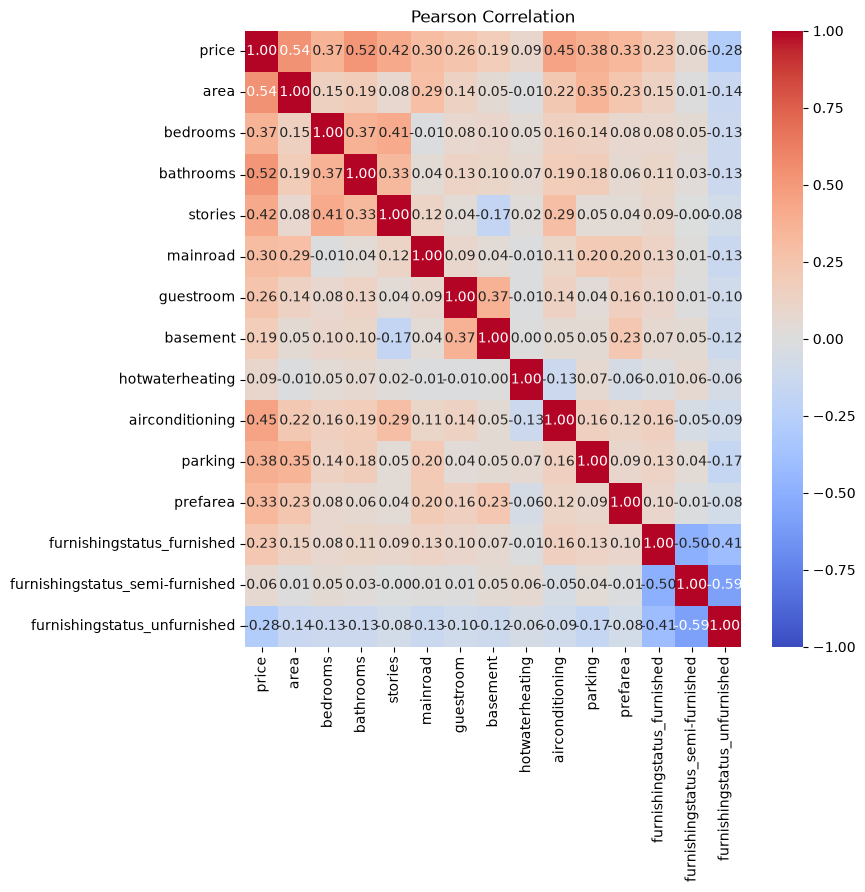

In [376]:
pearson_corr = df_housing.corr("pearson")
plt.figure(figsize=(8,8))
sns.heatmap(
  pearson_corr,
  cmap='coolwarm',
  vmin=-1,
  vmax=1,
  annot=True,
  fmt='.2f'
)
plt.title("Pearson Correlation")

#### Spearman Correlation

Text(0.5, 1.0, 'Spearman Correlation')

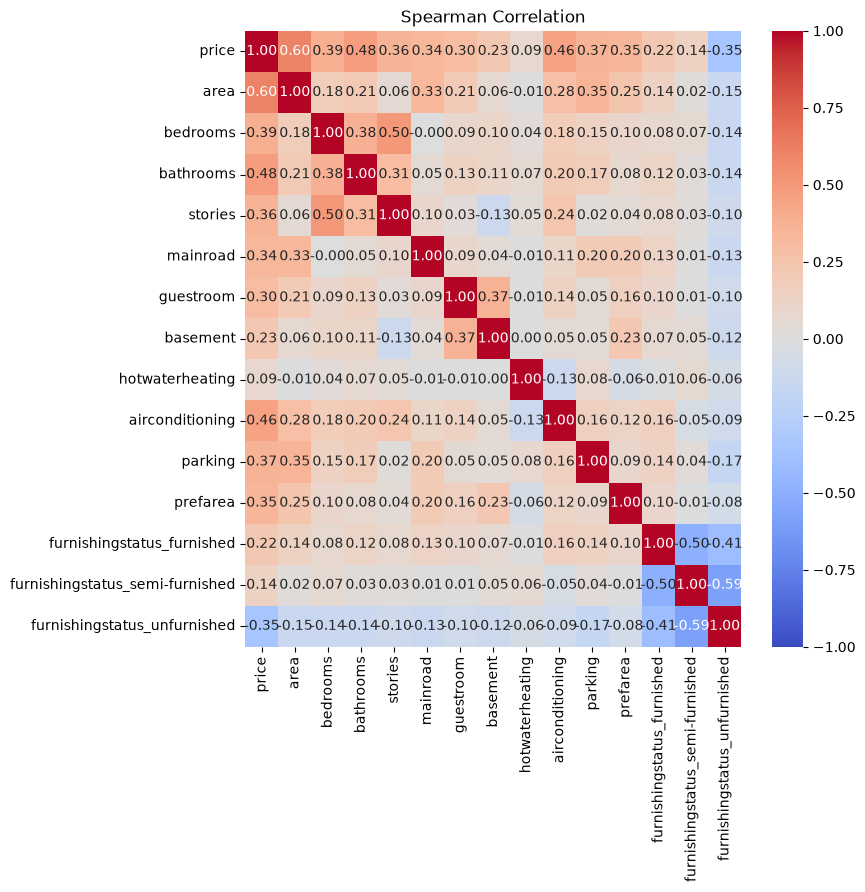

In [394]:
spearman_corr = df_housing.corr("spearman")
plt.figure(figsize=(8,8))
sns.heatmap(
  spearman_corr,
  cmap='coolwarm',
  vmin=-1,
  vmax=1,
  annot=True,
  fmt='.2f',
)
plt.title("Spearman Correlation")

## PCA Algorithm

In [378]:
X = df_model.copy()

preprocessor = ColumnTransformer(transformers=[
  ('num', StandardScaler(), X.select_dtypes("number").columns.to_list()),
  ('cat', OneHotEncoder(), X.select_dtypes("str").columns.to_list())
])

X_transformed = preprocessor.fit_transform(X=X)

model_pca2 = PCA(n_components=2)
model_pca3 = PCA(n_components=3)

X_pca3 = model_pca3.fit_transform(X=X_transformed)
X_pca2 = model_pca2.fit_transform(X=X_transformed)

df_pca2 = pd.DataFrame(X_pca2, columns=['PC1', 'PC2'])
df_pca3 = pd.DataFrame(X_pca3, columns=['PC1', 'PC2', 'PC3'])

In [379]:
df_pca2.head(10)

,PC1,PC2
0,5.198075,-1.133210
1,6.616273,-3.314874
2,4.182812,1.252790
3,5.197715,0.549891
4,3.965906,1.076895
5,4.400771,0.954672
6,5.479611,-2.088850
7,4.533123,-1.709151
8,4.194287,1.985016
9,3.978878,-0.511493


In [380]:
df_pca3.head(10)

,PC1,PC2,PC3
0,5.198075,-1.133210,-1.002728
1,6.616273,-3.314874,-0.556787
2,4.182812,1.252790,-0.799372
3,5.197715,0.549891,-0.506676
4,3.965906,1.076895,0.558931
5,4.400771,0.954672,-0.048381
6,5.479611,-2.088850,-0.535118
7,4.533123,-1.709151,-0.604321
8,4.194287,1.985016,0.438311
9,3.978878,-0.511493,0.505685


In [381]:
print(df_pca2.shape)
print(df_pca3.shape)

(545, 2)
(545, 3)


### Visualizar resultados

#### PCA - 2 Componentes

In [382]:
autovalores2 = model_pca2.components_
autovetores2 = model_pca2.explained_variance_

print(f"Autovalores:\n{autovalores2}\n")
print(f"Autovetores:\n{autovetores2}")

Autovalores:
[[ 0.50811106  0.34748666  0.29578074  0.33849918  0.28632461  0.22002279
   0.20210386  0.14128702  0.02363923  0.30160536  0.27206894  0.22811965
   0.06465971  0.01212475 -0.07678446]
 [-0.0147916   0.16412673 -0.32564765 -0.24981707 -0.48007371  0.21723043
   0.36742572  0.49021353 -0.09934947 -0.08331046  0.07496437  0.35797606
   0.01920946  0.00237232 -0.02158178]]

Autovetores:
[3.110137  1.5328115]


In [383]:
X_retransformed2 = model_pca2.inverse_transform(X=X_pca2)
reconstruction_error2 = mean_squared_error(X_transformed, X_retransformed2)
reconstruction_error2

0.53462853920358

In [384]:
r2_score(X_transformed, X_retransformed2)

0.31738196147728404

In [385]:
variancias = model_pca2.explained_variance_ratio_
variancias.sum()

np.float64(0.36624636881453354)

#### PCA - 3 Componentes

In [386]:
autovalores3 = model_pca3.components_
autovetores3 = model_pca3.explained_variance_
print(f"Autovalores:\n{autovalores3}\n")
print(f"Autovetores:\n{autovetores3}\n")

Autovalores:
[[ 5.08111060e-01  3.47486661e-01  2.95780744e-01  3.38499181e-01
   2.86324606e-01  2.20022788e-01  2.02103859e-01  1.41287019e-01
   2.36392272e-02  3.01605355e-01  2.72068944e-01  2.28119649e-01
   6.46597120e-02  1.21247458e-02 -7.67844579e-02]
 [-1.47916036e-02  1.64126727e-01 -3.25647653e-01 -2.49817069e-01
  -4.80073708e-01  2.17230429e-01  3.67425723e-01  4.90213534e-01
  -9.93494665e-02 -8.33104588e-02  7.49643706e-02  3.57976059e-01
   1.92094608e-02  2.37232214e-03 -2.15817829e-02]
 [-3.08616966e-02 -3.56338715e-01  3.08873940e-01  2.45758053e-01
   7.21953688e-02 -4.28765894e-01  4.12878081e-01  4.72138757e-01
   6.30901334e-02 -3.84282894e-02 -3.57223254e-01 -1.45378803e-02
  -1.68955640e-02  1.64906054e-02  4.04958591e-04]]

Autovetores:
[3.110137  1.5328115 1.2806635]



In [387]:
X_recovered3 = model_pca3.inverse_transform(X=X_pca3)
reconstruction_error3 = mean_squared_error(X_transformed, X_recovered3)
reconstruction_error3

0.4494076284837575

In [388]:
r2_score(X_transformed, X_recovered3)

0.4027782168641213

In [389]:
variancias = model_pca3.explained_variance_ratio_
variancias.sum()

np.float64(0.4672680271458968)

## Visualização da Redução de Dimensionalidade

### 2D

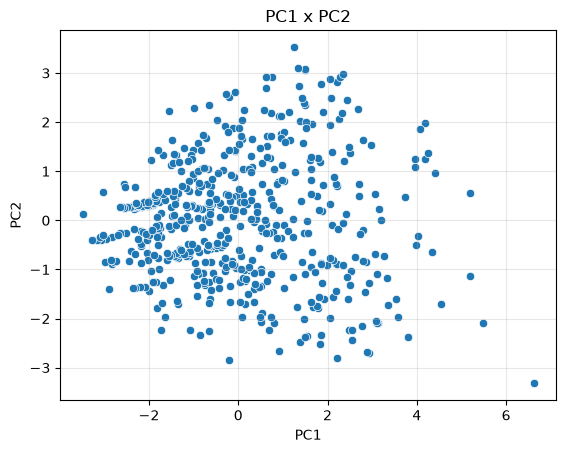

In [ ]:
sns.scatterplot(
  df_pca2,
  x='PC1',
  y='PC2',
)
plt.title("PC1 x PC2")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(visible=True, alpha=0.3)

### 3D

In [395]:
import plotly.io as pio
pio.renderers.default = 'browser'

fig = px.scatter_3d(
  data_frame=df_pca3,
  x='PC1',
  y='PC2',
  z='PC3',
  title="PCA View - 3 Components",
)
fig.show()